# **Convolutional Autoencoder for T-Shirt Image Reconstruction**

In [107]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Required Libraries**

In [108]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from sklearn.metrics import mean_squared_error

In [109]:
folder = "/content/drive/MyDrive/sem_6/deeplearning/preprocesado"

## **Data Loading**


In [110]:
def load_images(folder):
    images = []
    for file in os.listdir(folder):
        if file.endswith((".jpg", ".jpeg", ".png")):
            img = load_img(os.path.join(folder, file))
            img = img_to_array(img)
            images.append(img)
    return np.array(images, dtype="uint8")

X = load_images(folder)
print("Number of images:", len(X))
print("Shape:", X.shape)

Number of images: 686
Shape: (686, 128, 128, 3)


## **Train/ Test**


In [111]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (548, 128, 128, 3)
Test: (138, 128, 128, 3)


## **Visualizations Original Images**


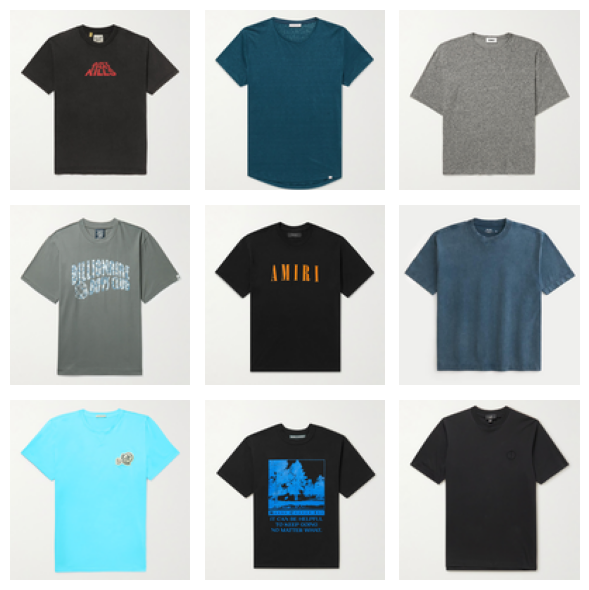

In [112]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


## **Data Augmentation**

In [113]:
datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.02,
    height_shift_range=0.02,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

To improve model robustness, small random transformations are applied to the training images:

- Rotation (±10 degrees)
- Width and height shift (±5%)
- Zoom (±10%)
- Horizontal flip

## **Data Augmentation Visualization**

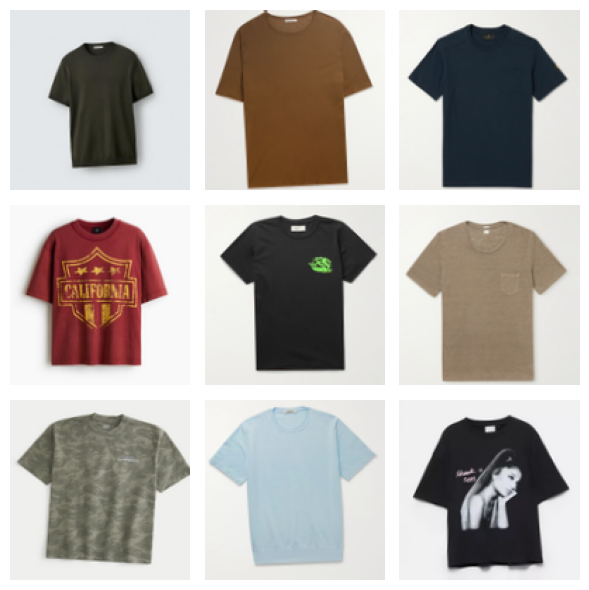

In [114]:
X_batch = next(datagen.flow(X_train, batch_size=9))

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_batch[i].astype("uint8"))
    plt.axis("off")
plt.tight_layout()
plt.show()

## **Normalization**

In [115]:
X_train_norm = X_train.astype("float32") / 255.
X_test_norm = X_test.astype("float32") / 255.

We convert pixel values from integers in the range [0, 255] to floating values in the range [0, 1].

This is necessary because:

- It improves numerical stability.
- It accelerates convergence during optimization.
- It prevents large gradient updates caused by large input values.

The normalization is performed by dividing each pixel value by 255.

## **Defining the Latent Space**

In [116]:
latent_dim = 128

Here, we define the dimensionality of the latent space.

The latent dimension controls how much compressed information the model can store about each image.

A smaller latent dimension forces stronger compression, while a larger dimension allows more detailed representations.

In this implementation, we use a latent dimension of 64.

## **Sampling Layer (Reparameterization Trick)**

In [117]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        # KL Divergence
        beta = 0.005

        kl_loss = beta * (-0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        ))

        self.add_loss(kl_loss)
        return z

This custom layer implements the reparameterization trick, which is a key component of Variational Autoencoders.

Instead of directly sampling from a normal distribution, we compute:

z = μ + σ * ε

Where:
- μ is the latent mean
- σ is derived from the log variance
- ε is sampled from a standard normal distribution

This formulation allows backpropagation through the sampling process.

Additionally, this layer computes and adds the KL Divergence loss, which regularizes the latent space to follow a standard normal distribution.

## **Encoder**

In [118]:
encoder_inputs = layers.Input(shape=(128, 128, 3))

x = layers.Conv2D(32, 3, activation='relu', padding='same')(encoder_inputs)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, z, name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 64, 64,    │          0 │ conv2d_28[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_13    │ (None, 32, 32,    │          0 │ conv2d_29[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_13… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 16, 16,    │          0 │ conv2d_30[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32768)     │          0 │ max_pooling2d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │  8,388,864 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 128)       │     32,896 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 128)       │     32,896 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_4          │ (None, 128)       │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,547,904 (32.61 MB)

 Trainable params: 8,547,904 (32.61 MB)

 Non-trainable params: 0 (0.00 B)

The encoder maps input images into a probabilistic latent representation.

It consists of convolutional layers followed by max pooling layers to progressively reduce spatial dimensions while increasing feature depth.

After flattening the feature maps, two dense layers are used to compute:

- z_mean: the mean of the latent distribution
- z_log_var: the logarithm of the variance

These parameters define the probability distribution from which latent vectors are sampled.

## **Decoder**

In [119]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(16 * 16 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((16, 16, 128))(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32768)          │     4,227,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_14 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,467,779 (17.04 MB)

 Trainable params: 4,467,779 (17.04 MB)

 Non-trainable params: 0 (0.00 B)

The decoder reconstructs images from sampled latent vectors.

It first expands the latent vector using a dense layer and reshapes it into a small feature map.

Then, convolutional and upsampling layers progressively increase the spatial dimensions until the original image size (64×64×3) is restored.

The final layer uses a sigmoid activation function to ensure output pixel values remain in the range [0,1].

## **Variational Autoencoder**

In [120]:
outputs = decoder(encoder(encoder_inputs))
vae = Model(encoder_inputs, outputs, name="VAE_Tshirts")

In this step, we connect the encoder and decoder to form the full VAE model.

The encoder compresses the image into a latent distribution.
A latent sample is drawn using the sampling layer.
The decoder reconstructs the image from that sample.

The KL divergence loss is automatically added during the sampling process.

## **Model Compilation**

In [121]:
vae.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse"
)

The model is compiled using the Adam optimizer.

We use Mean Squared Error (MSE) as the reconstruction loss.

The total loss of the VAE is composed of:

- Reconstruction Loss (MSE)
- KL Divergence (added inside the sampling layer)

This combination ensures both accurate reconstruction and a well-structured latent space.

## **Model Training**

In [122]:
history = vae.fit(
    X_train_norm,
    X_train_norm,
    epochs=200,
    batch_size=32,
    validation_data=(X_test_norm, X_test_norm)
)

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 360ms/step - loss: 0.1172 - val_loss: 0.0649
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0620 - val_loss: 0.0467
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0445 - val_loss: 0.0309
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0304 - val_loss: 0.0266
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0272 - val_loss: 0.0236
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0242 - val_loss: 0.0233
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0228 - val_loss: 0.0219
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0218 - val_loss: 0.0204
Epoch 9/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0209 - val_loss: 0.0194
Epoch 10/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0199 - val_loss: 0.0206
Epoch 11/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0197 - val_loss: 0.0189
Epoch 12/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/st

The model is trained to reconstruct input images.

During training:

- The encoder learns a probabilistic latent representation.
- The decoder learns to reconstruct images from latent samples.
- The KL divergence regularizes the latent space.

Validation data is used to monitor generalization performance and detect overfitting.

## **Training Loss**

dict_keys(['loss', 'val_loss'])


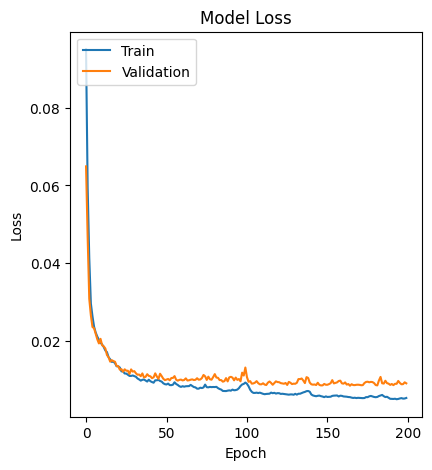

In [123]:
def plot_history(history):

    plt.figure(figsize=(10, 5))

    # summarize history for loss
    plt.subplot(122)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

print(history.history.keys())
plot_history(history)

## **Image Generation**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


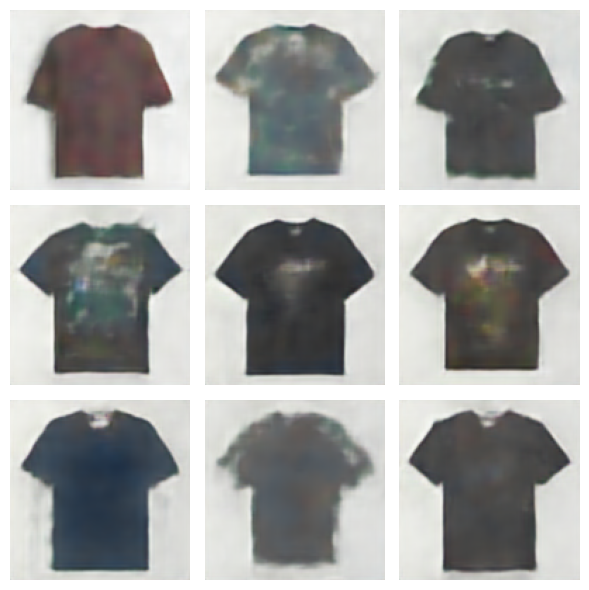

In [135]:
random_latent_vectors = np.random.normal(size=(9, latent_dim))
generated_images = decoder.predict(random_latent_vectors)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.tight_layout()
plt.show()


One of the main advantages of a Variational Autoencoder is its generative capability.

After training, we can sample random vectors from a standard normal distribution in the latent space.

These random latent vectors are passed through the decoder to generate entirely new images that were not present in the training dataset.

This demonstrates that the model has learned a structured and meaningful latent representation.

## **MSE**

In [136]:
reconstructed = vae.predict(X_test_norm)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [137]:
import numpy as np

mse = np.mean((X_test_norm - reconstructed) ** 2)
print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.0072289347


In [138]:
vae.save("vae_full_model.keras")